In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
nav = pd.read_csv("C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\raw\\nav_history_clean.csv")

fund = pd.read_csv("C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\raw\\01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

df = nav.merge(

    fund[["amfi_code", "scheme_name"]],

    on="amfi_code",

    how="left"

)

display(df.head())

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [3]:
df["running_max"] = (

    df.groupby("scheme_name")["nav"]

      .cummax()

)

df["drawdown"] = (

    df["nav"] / df["running_max"]

) - 1

display(df.head())

,amfi_code,date,nav,scheme_name,running_max,drawdown
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,520.4608,0.000000
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,520.4608,-0.010306
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,521.7239,0.000000
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,521.7239,-0.011377
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,521.7239,-0.012574


In [4]:
results = []

for scheme, temp in df.groupby("scheme_name"):

    temp = temp.sort_values("date").reset_index(drop=True)

    idx = temp["drawdown"].idxmin()

    trough = temp.loc[idx]

    peak = temp.loc[:idx]

    peak_idx = peak["nav"].idxmax()

    peak_row = peak.loc[peak_idx]

    results.append({

        "Scheme Name": scheme,

        "Peak Date": peak_row["date"],

        "Trough Date": trough["date"],

        "Maximum Drawdown (%)": round(

            trough["drawdown"] * 100,

            2

        )

    })

mdd_df = pd.DataFrame(results)

In [5]:
mdd_df = mdd_df.sort_values(

    "Maximum Drawdown (%)"

).reset_index(drop=True)

display(mdd_df)

,Scheme Name,Peak Date,Trough Date,Maximum Drawdown (%)
0,SBI Small Cap Fund - Direct Plan - Growth,2023-01-17,2025-10-28,-52.57
1,Axis Small Cap Fund - Regular - Growth,2025-05-22,2026-05-11,-51.68
2,ABSL Small Cap Fund - Regular - Growth,2024-11-21,2026-05-11,-35.45
3,DSP Small Cap Fund - Regular - Growth,2024-05-03,2025-01-03,-31.17
4,SBI Small Cap Fund - Regular Plan - Growth,2024-08-28,2025-05-14,-28.71
5,UTI Mid Cap Fund - Regular - Growth,2025-01-07,2026-04-27,-28.00
6,HDFC Top 100 Fund - Regular Plan - Growth,2022-03-30,2022-09-15,-24.73
7,Kotak Emerging Equity Fund - Regular - Growth,2023-11-09,2024-10-17,-24.00
8,Nippon India Small Cap Fund - Regular - Growth,2025-04-09,2026-02-20,-23.34
9,Axis Bluechip Fund - Direct - Growth,2022-02-24,2023-05-22,-21.75


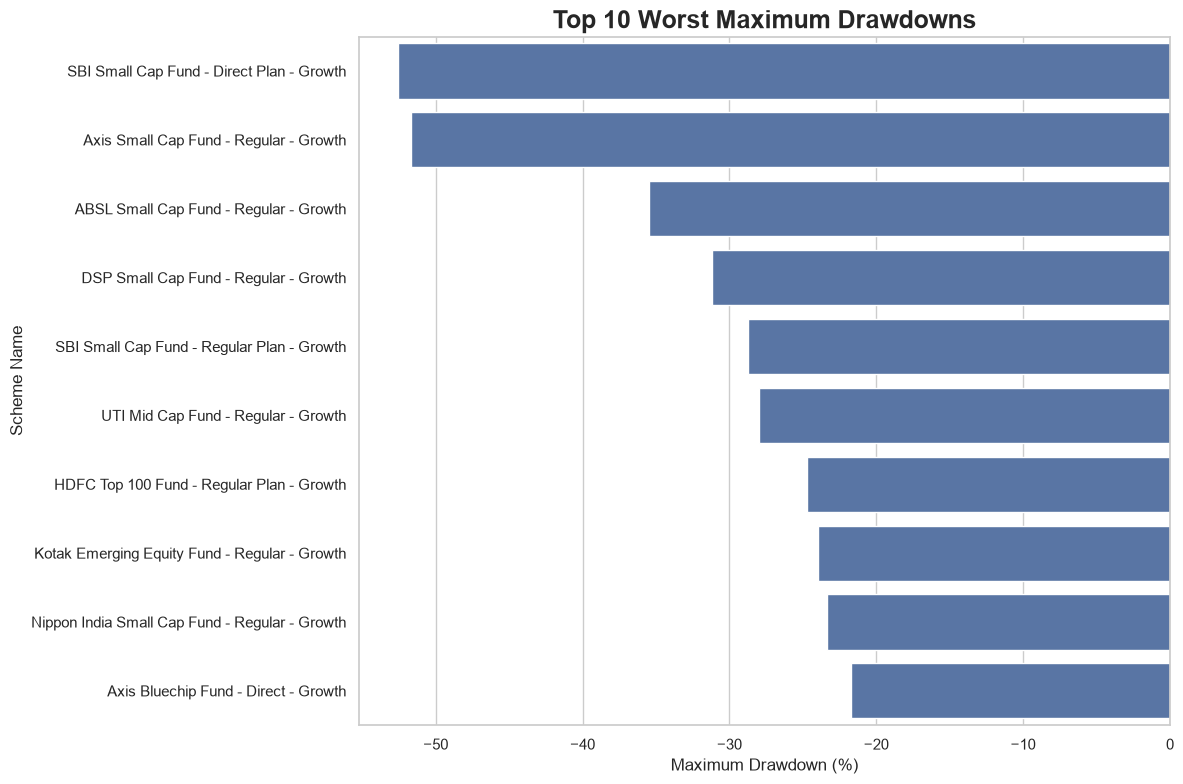

In [6]:
plt.figure(figsize=(12,8))

sns.barplot(

    data=mdd_df.head(10),

    y="Scheme Name",

    x="Maximum Drawdown (%)"

)

plt.title(

    "Top 10 Worst Maximum Drawdowns",

    fontsize=18,

    weight="bold"

)

plt.tight_layout()

plt.show()

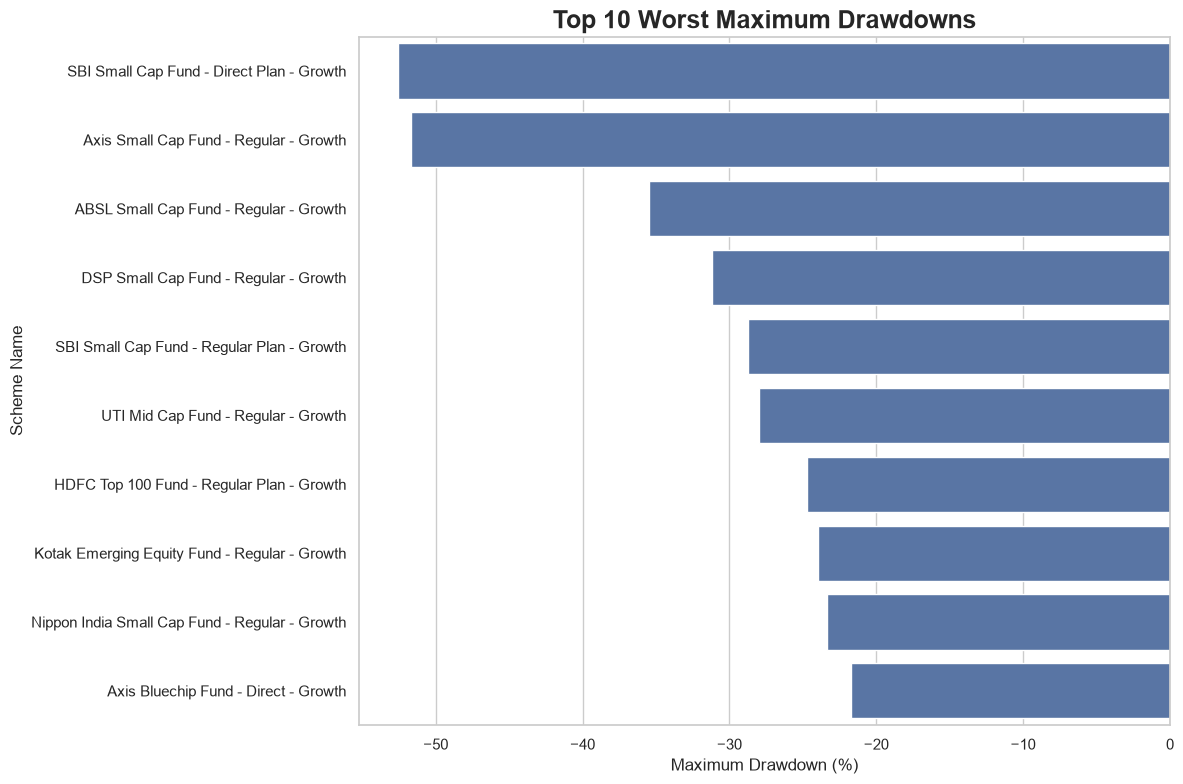

✅ Chart Saved Successfully


In [7]:
os.makedirs("dashboard", exist_ok=True)

plt.figure(figsize=(12,8))

sns.barplot(

    data=mdd_df.head(10),

    y="Scheme Name",

    x="Maximum Drawdown (%)"

)

plt.title(

    "Top 10 Worst Maximum Drawdowns",

    fontsize=18,

    weight="bold"

)

plt.tight_layout()

plt.savefig(

    "dashboard/maximum_drawdown_top10.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✅ Chart Saved Successfully")

In [8]:
os.makedirs("data/processed", exist_ok=True)

mdd_df.to_csv(

    "C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\processed\\maximum_drawdown_ranking.csv",

    index=False

)

print("✅ CSV Saved Successfully")

✅ CSV Saved Successfully


In [9]:
worst = mdd_df.iloc[0]

print("="*60)

print("Worst Maximum Drawdown")

print("="*60)

print("Fund :", worst["Scheme Name"])
print("Peak Date :", worst["Peak Date"])
print("Trough Date :", worst["Trough Date"])
print("Maximum Drawdown :", worst["Maximum Drawdown (%)"], "%")

Worst Maximum Drawdown
Fund : SBI Small Cap Fund - Direct Plan - Growth
Peak Date : 2023-01-17 00:00:00
Trough Date : 2025-10-28 00:00:00
Maximum Drawdown : -52.57 %


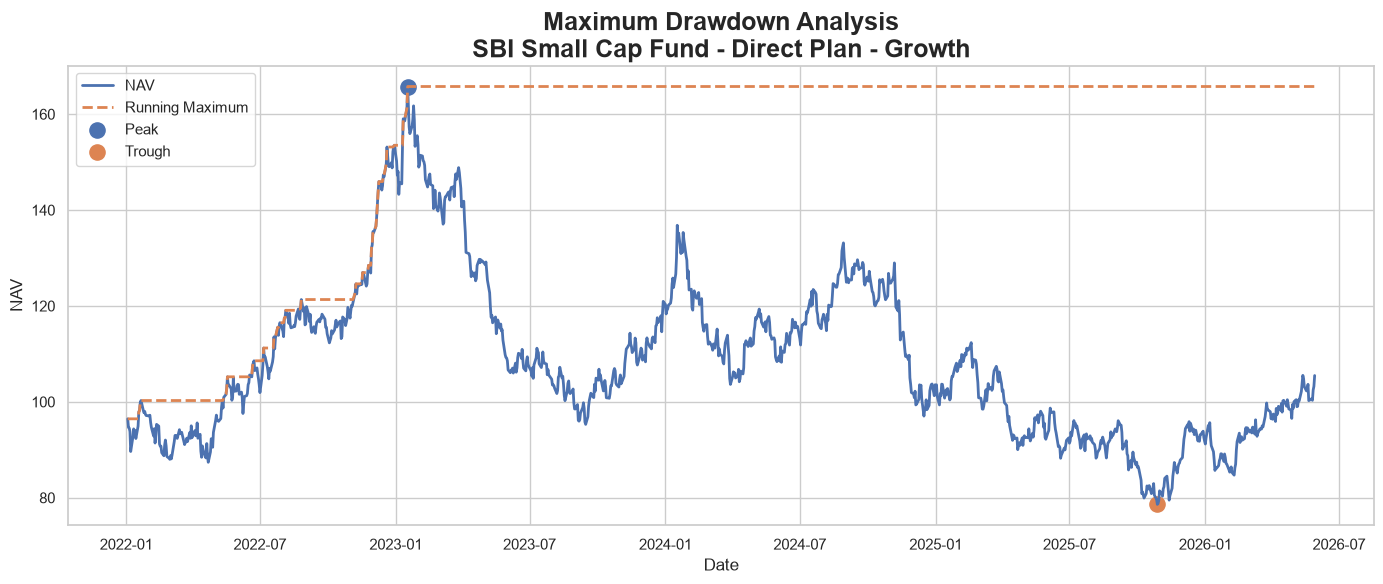

✅ worst_drawdown_analysis.png saved successfully


In [10]:
# Find Worst Fund

worst_fund = mdd_df.iloc[0]["Scheme Name"]

worst_df = df[df["scheme_name"] == worst_fund].copy()

plt.figure(figsize=(14,6))

plt.plot(

    worst_df["date"],

    worst_df["nav"],

    label="NAV",

    linewidth=2

)

plt.plot(

    worst_df["date"],

    worst_df["running_max"],

    label="Running Maximum",

    linewidth=2,

    linestyle="--"

)

# Mark Peak

peak_date = mdd_df.iloc[0]["Peak Date"]

peak_nav = worst_df.loc[
    worst_df["date"] == peak_date,
    "nav"
].values[0]

plt.scatter(
    peak_date,
    peak_nav,
    s=120,
    label="Peak"
)

# Mark Trough

trough_date = mdd_df.iloc[0]["Trough Date"]

trough_nav = worst_df.loc[
    worst_df["date"] == trough_date,
    "nav"
].values[0]

plt.scatter(
    trough_date,
    trough_nav,
    s=120,
    label="Trough"
)

plt.title(

    f"Maximum Drawdown Analysis\n{worst_fund}",

    fontsize=18,

    weight="bold"

)

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.tight_layout()

plt.savefig(

    "dashboard/worst_drawdown_analysis.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✅ worst_drawdown_analysis.png saved successfully")

## Insight: Maximum Drawdown Analysis

Maximum Drawdown measures the largest percentage decline from a fund's previous peak NAV before recovering. Funds with smaller drawdowns are generally more resilient during market downturns, while deeper drawdowns indicate higher downside risk.

**Chart Reference:** Top 10 Worst Maximum Drawdowns

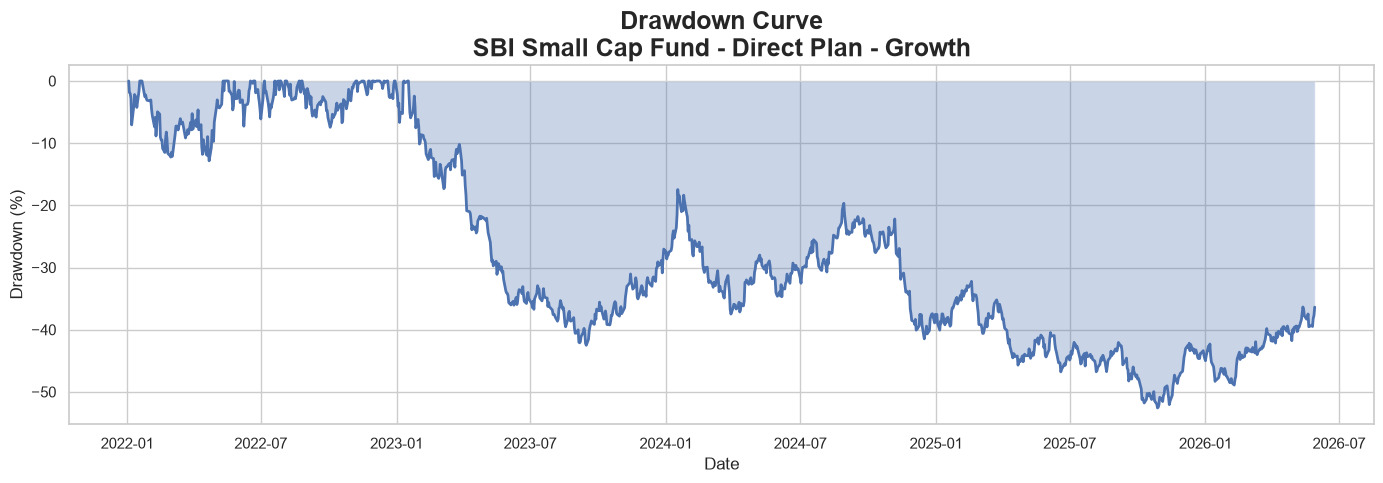

✅ drawdown_curve.png saved successfully


In [11]:
plt.figure(figsize=(14,5))

plt.plot(

    worst_df["date"],

    worst_df["drawdown"] * 100,

    linewidth=2

)

plt.fill_between(

    worst_df["date"],

    worst_df["drawdown"] * 100,

    0,

    alpha=0.3

)

plt.title(

    f"Drawdown Curve\n{worst_fund}",

    fontsize=18,

    weight="bold"

)

plt.xlabel("Date")

plt.ylabel("Drawdown (%)")

plt.tight_layout()

plt.savefig(

    "dashboard/drawdown_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✅ drawdown_curve.png saved successfully")